# Demo 5 — Small optogenetic input (1-D ring)

Stimulate a single small spot and measure its *influence* on the rest of the
network: the change in steady-state rate, `response(baseline + opto) −
response(baseline)`. A Mexican-hat network produces a center-surround influence
(nearby units excited, farther units suppressed); a random network does not.

In [1]:
# --- make the package importable ---------------------------------------------
# The package files live flat in this repository folder (itself named
# "cortical_rate_model"), so we add the PARENT directory to the path.
import sys, pathlib
_cwd = pathlib.Path.cwd()
_parent = _cwd.parent if _cwd.name == "cortical_rate_model" else _cwd
sys.path.insert(0, str(_parent))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cortical_rate_model as crm
from cortical_rate_model import Layout, RateNetwork, EIRateNetwork, make_connectivity, inputs, plotting
print("cortical_rate_model", crm.__version__)

cortical_rate_model 0.1.0


In [2]:
def build_net(kind, layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Single-population network with its recurrent gain set by spectral radius."""
    W = make_connectivity(kind, layout, **params)
    W = crm.scale_spectral_radius(W, spectral_radius)
    return RateNetwork(W, layout=layout, nonlinearity=nonlinearity)

def build_ei(layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Two-population E/I network with its recurrent gain set by spectral radius."""
    W, meta = make_connectivity("ei_homogeneous", layout, normalise="spectral",
                                spectral_radius=spectral_radius, **params)
    return EIRateNetwork(W, meta=meta, layout=layout, nonlinearity=nonlinearity)

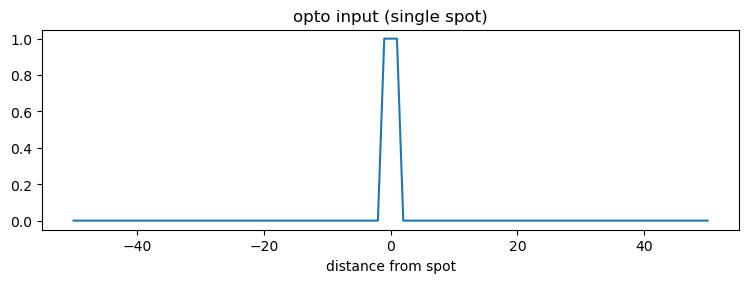

In [3]:
ring = Layout(101, periodic=True)     # odd size -> a well-defined centre
center = ring.num_units // 2
baseline = inputs.uniform_input(ring, 1.0)
opto = inputs.local_stimulation(ring, center=center, radius=1.0, intensity=1.0,
                                baseline=0.0)
drive = baseline + opto

x = np.arange(ring.num_units) - center       # signed distance from the spot
plt.figure(figsize=(9, 2.6)); plt.plot(x, opto)
plt.title("opto input (single spot)"); plt.xlabel("distance from spot"); plt.show()

## Influence profile for different connectivity profiles

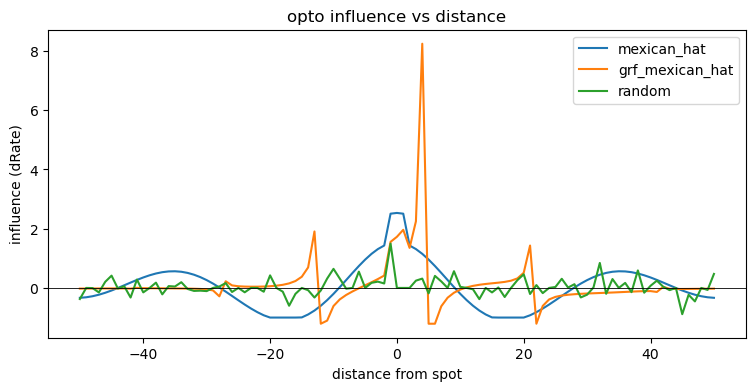

In [4]:
profiles = {
    "mexican_hat":     dict(sigma=6.0, inh_factor=2.0),
    "grf_mexican_hat": dict(sigma=6.0, inh_factor=2.0, grf_strength=0.5),
    "random":          dict(g=1.0),
}
plt.figure(figsize=(9, 4))
for kind, params in profiles.items():
    net = build_net(kind, ring, spectral_radius=0.95, **params)
    r_base = net.steady_state(baseline, n_steps=400).numpy()
    r_opto = net.steady_state(drive, n_steps=400).numpy()
    influence = r_opto - r_base
    plt.plot(x, influence, label=kind)
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("distance from spot"); plt.ylabel("influence (dRate)")
plt.title("opto influence vs distance"); plt.legend(); plt.show()

## E/I network

Stimulate the excitatory population and read out the excitatory influence.

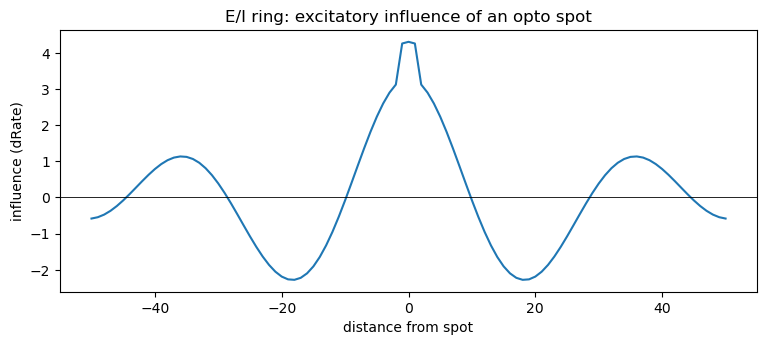

In [5]:
ei = build_ei(ring, sigma_ee=6.0, sigma_ei=12.0, sigma_ie=6.0, sigma_ii=12.0)
base_ei = inputs.to_ei_input(exc_input=inputs.uniform_input(ring, 1.0),
                             num_units=ring.num_units)
opto_ei = inputs.to_ei_input(exc_input=opto, num_units=ring.num_units)
r_base = ei.steady_state(base_ei, n_steps=500).numpy()
r_opto = ei.steady_state(base_ei + opto_ei, n_steps=500).numpy()
infl_exc, _ = ei.split_activity(r_opto - r_base)

plt.figure(figsize=(9, 3.4)); plt.plot(x, infl_exc)
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("distance from spot"); plt.ylabel("influence (dRate)")
plt.title("E/I ring: excitatory influence of an opto spot"); plt.show()